# Pandas for Data Preparation

Mempelajari fungsi-fungsi dasar yang dapat dilakukan menggunakan pandas dalam melakukan eksploarasi data. Materi ini merupakan tambahan dari materi sebelumnya

## Data Frame and Series

DataFrame adalah struktur data 2 dimensi yang berbentuk tabular (mempunyai baris dan kolom) pada Pandas

Series adalah struktur data 1 dimensi yang berbentuk tabular (mempunyai baris dan kolom) pada Pandas


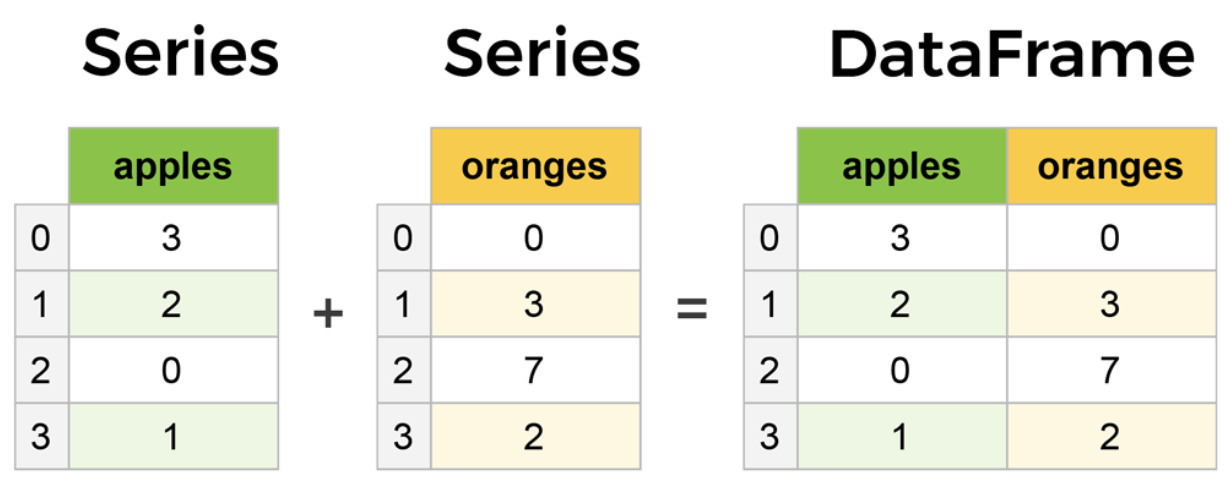!

In [ ]:
import pandas as pd
df = pd.DataFrame([['a','b'],['a','b'], ['a','b']])

df[0].str.upper()

## Dataframe Axis

A DataFrame object has two axes: “axis 0” and “axis 1”. “axis 0” represents columns and “axis 1” represents rows.

Series object has only one axis, so this parameter always equals 0 for it. 


Now it’s clear that Series and DataFrame share the same direction for “axis 0” – it goes along rows direction.

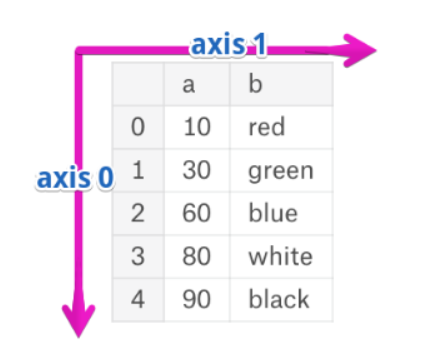

In [ ]:
import pandas as pd
# Load dataset kotor
telco_data = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_dirty = pd.read_csv(telco_data)
df_dirty.head()

In [101]:
df_trial = df_dirty.copy()
# df_trial.columns = [col[0].upper() + col[1:] for col in df_trial.columns]
df_trial.columns = [col.capitalize() for col in df_trial.columns]

df_trial.head()

,Id,Customerid,Gender,Seniorcitizen,Partner,Dependents,Tenure,Phoneservice,Multiplelines,Internetservice,...,Techsupport,Streamingtv,Streamingmovies,Contract,Paperlessbilling,Paymentmethod,Monthlycharges,Totalcharges,Churn,Consumercategory
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed,Silver
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed,Gold
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned,Gold
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed,Gold
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned,Gold


##  Informasi DataFrame

```python
    dataframe.columns # daftar kolom pada dataframe 
    
    dataframe.info() # informasi dataframe, kolom tipe data dsb.
    
    dataframe.shape # dimensi dataframe
    
    dataframe.size # jumlah data pada dataframe
    
```

### Hint for Class/Function 

Use:
```python 
help(type(dataframe.columns))
```

In [ ]:
df_trial.columns

df_trial[['Tenure', 'MonthlyCharges', 'TotalCharges']]

# df_trial.iloc[:, 1:3]

# Selecting and Filtering Data

## Mengambil baris dan kolom

### Slicing

#### Mengambil seluruh baris dari sebagian kolom (row slicing)

Caranya adalah:
``` python
dataframe['index']
```


#### Mengambil seluruh kolom dari sebagian baris (columns slicing)
Caranya adalah
``` python
dataframe['namakolom']
```

``` python
dataframe.namakolom
```
Untuk mencari nama kolom:

``` python
dataframe.columns
```

#### Mengambil sebagian baris pada sebagian kolom (row-column slicing)
Caranya adalah:

 ``` python
dataframe['namakolom']['index']
```

### Menggunakan .loc
> Memilih baris atau kolom dengan label tertentu dari index.

```python
dataframe1.loc["baris", "kolom"]


```


In [ ]:
# kita akan coba mengakses sampai dengan index ke 4 (baris ke-5) 
# mulai dari Kolom 'Gender' s.d. kolom 'Partner'
df_dirty.loc[:4, 'Gender':'Partner']

### Menggunakan iloc

> Memilih baris atau kolom dengan label tertentu dari posisi index (integers).

```python
dataframe1.iloc[baris, kolom]

dataframe1.iloc[start:end (baris), start:end(kolom)]
```

In [ ]:
# kita akan coba mengakses dari index ke-5 s.d. index ke-9 
# dari kolom 1 s.d. 5
df_dirty.iloc[5:10, 0:3]

### Filtering data

Cara pertama untuk melakukan filter adalah menggunakan ```conditional```.

```python
dataframe1[conditional] #yang nilainya true akan ditampilkan

```

Yang kedua menggunakan ```query```.

```python
df.query('20 < Age < 40')[:5]

```

In [73]:
df_dirty.head()

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


In [81]:
# Tampilkan data yang Gendernya Female
# df_dirty[df_dirty['gender'] == 'Female'][['gender', 'SeniorCitizen']]

# Tampilkan data yang Gendernya Male, tampilkan kolom MonthlyCharges dan TotalCharges
df_dirty[df_dirty['gender']== 'Male'][['gender', 'MonthlyCharges', 'TotalCharges']]


,gender,MonthlyCharges,TotalCharges
1,Male,56.95,1889.5
2,Male,53.85,108.15
3,Male,42.30,1840.75
6,Male,89.10,1949.4
9,Male,56.15,3487.95
...,...,...,...
7033,Male,69.50,2625.25
7035,Male,78.70,1495.1
7038,Male,84.80,1990.5
7041,Male,74.40,306.6


In [ ]:
df_dirty['Contract'].unique()

## Sorting Data

> Mengurutkan data berdasarkan valuenya.

Untuk melakukan sorting data pada DataFrame:
1. Hanya satu kolom:
```python
DataFrame.sort_values(by='', ascending=False)
```
2. Beberapa kolom:
```python
DataFrame.sort_values(["b", "c"], ascending = (False, True))
```

In [82]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7043 non-null   int64  
 1   customerID        7043 non-null   str    
 2   gender            7043 non-null   str    
 3   SeniorCitizen     7043 non-null   str    
 4   Partner           7043 non-null   str    
 5   Dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   str    
 8   MultipleLines     7043 non-null   str    
 9   InternetService   7043 non-null   str    
 10  OnlineSecurity    7043 non-null   str    
 11  OnlineBackup      7043 non-null   str    
 12  DeviceProtection  7043 non-null   str    
 13  TechSupport       7043 non-null   str    
 14  StreamingTV       7043 non-null   str    
 15  StreamingMovies   7043 non-null   str    
 16  Contract          7043 non-null   str    
 17  Paperl

In [87]:
# Untuk melihat data dengan Tenure paling lama
df_dirty.sort_values(by='tenure', ascending=False)['tenure'].unique()

array([72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56,
       55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39,
       38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22,
       21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,
        4,  3,  2,  1,  0])

## Summarizing Data
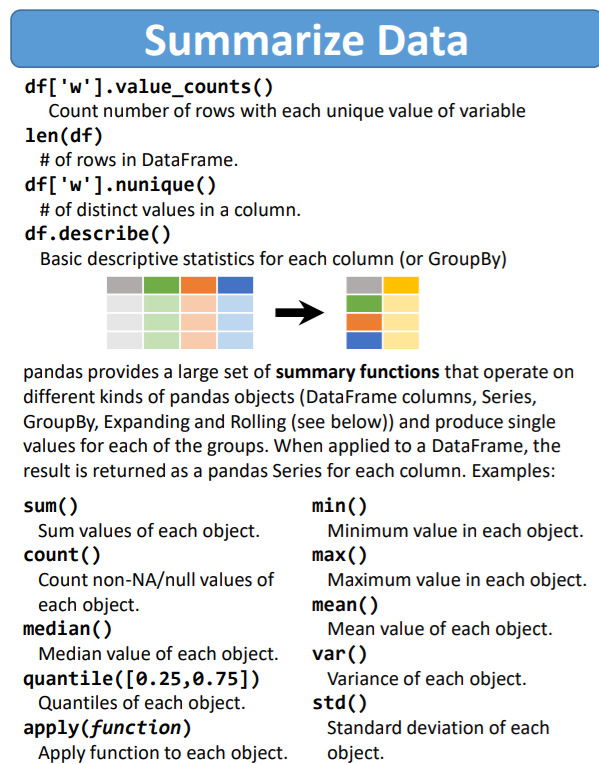

In [92]:
print(df_dirty['gender'].value_counts())

print()
print(df_dirty['Churn'].value_counts())

print()
df_dirty.describe()

gender
Male      3555
Female    3488
Name: count, dtype: int64

Churn
Stayed     5174
Churned    1869
Name: count, dtype: int64



,id,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,3521.000000,32.371149,64.923456
std,2033.283305,24.559481,33.450398
min,0.000000,0.000000,9.200000
25%,1760.500000,9.000000,35.500000
50%,3521.000000,29.000000,70.350000
75%,5281.500000,55.000000,89.850000
max,7042.000000,72.000000,1290.000000


In [ ]:
def categorize_customer(monthly_charge):
    if monthly_charge <= 30:
        return 'Silver'
    elif monthly_charge > 30:
        return 'Gold'
    else:
        return 'Uncategorized'

# versi menggunakan function
df_dirty['ConsumerCategory'] = df_dirty['MonthlyCharges'].apply(categorize_customer)

# versi menggunakan lambda
df_dirty['ConsumerCategory'] = df_dirty['MonthlyCharges'].apply(lambda monthly_charge: 'Silver' if monthly_charge <= 30 else 'Gold')

df_dirty.head()

,id,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ConsumerCategory
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed,Silver
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed,Gold
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned,Gold
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed,Gold
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned,Gold


# String Manipulation

### Python String Method

- String merupakan tipe data "teks", didefinisikan dengan tanda kutip (' atau ").
- Jika menggunakan kutip dua " untuk definisi string, maka bisa digunakan kutip satu di dalam teks, begitu juga sebaliknya


Beberapa contoh string method di Python:

| Method       | Deskripsi                                                                                          |
|--------------|----------------------------------------------------------------------------------------------------|
| capitalize() | Ubah karakter pertama pada string menjadi kapital                                                  |
| find('str')       | Cari string di dalam suatu string, dengan outputnya adalah posisi indeks string tersebut ditemukan |
| lower()      | Mengubah semua karakter di string menjadi huruf kecil                                              |
| lstrip()     | Menghilangkan spasi berlebih pada bagian kiri string                                               |
| rstrip()     | Menghilangkan spasi berlebih pada bagian kanan string                                              |
| split('str')      | Memotong string pada karakter yang ditentukan, dan dioutput sebagai list                           |
| strip()      | Menghilangkan spasi berlebih pada semua sisi string                                                |
| swapcase()   | Mengganti huruf besar pada string menjadi kecil, dan sebaliknya                                    |
| title()      | Mengubah huruf pertama pada tiap kata didalam string sebagai huruf kapital                         |
| upper()      | Mengubah semua karakter di string menjadi huruf besar           

In [105]:
#Contoh
text = " Halo Dunia  "
text.strip()

'Halo Dunia'

In [107]:
# buatlah semua karakter dalam string menjadi huruf kecil
text = 'LIveRpoOl is ThE BeSt PrEmiEr LeAgUe TeAm'

#Jawaban
text.lower()


'liverpool is the best premier league team'

In [117]:
# gunakanlah method .split() pada string berikut, pisahkan apabila terdapat spasi
text = 'LIveRpoOl is ThE BeSt PrEmiEr LeAgUe TeAm'

#Jawaban
text.split()


['LIveRpoOl', 'is', 'ThE', 'BeSt', 'PrEmiEr', 'LeAgUe', 'TeAm']

### Tipe Data Teks di Pandas

Data teks disimpan di Pandas dalam format Object atau String.
Di Pandas, apabila menyimpan string menjadi series/dataframe otomatis menjadi tipe data `Object'

In [118]:
pd.Series(["1", "2", "3"])


0    1
1    2
2    3
dtype: str

In [123]:
# untuk membuat tipe datanya string dari series, diberikan argumen dtype 
pd.Series(["1", "a", "3"], dtype="string")

0    1
1    a
2    3
dtype: string

#### Konversi tipe data di Pandas

In [125]:
s = pd.Series(["1", "a", "3"])
s

0    1
1    a
2    3
dtype: str

In [126]:
#konversi menjadi tipe data string
s2 = s.astype("string")
s2

0    1
1    a
2    3
dtype: string

In [127]:
#konversi menjadi tipe data int64
s_int = s.astype("int64")
s_int

ValueError: invalid literal for int() with base 10: 'a'

### Pandas String Method

`Series` memiliki beberapa fungsi dasar yang mempermudah proses manipulasi string pada setiap elemen array.  Data kosong / NA otomatis dikecualikan.

Syntax: `NamaSeries.str.Method()`

String method di Pandas mirip dengan di Python secara umum, antara lain:


| Method       | Deskripsi                                                                                          |
|--------------|----------------------------------------------------------------------------------------------------|
| upper()      | Mengubah semua karakter di string menjadi huruf besar                                              |
| lower()      | Mengubah semua karakter di string menjadi huruf kecil                                              |
| len()        | Menghitung jumlah karakter di suatu string                                                         |
| isdigit()    | Menentukan apakah semua karakter merupakan suatu digit                                             |
| match('str')      | Menentukan apakah suatu pola dapat ditemukan pada suatu string                                     |
| lstrip()     | Menghilangkan spasi berlebih pada bagian kiri string                                               |
| rstrip()     | Menghilangkan spasi berlebih pada bagian kanan string                                              |
| strip()      | Menghilangkan spasi berlebih pada semua sisi string                                                |
| split('str')      | Memotong string pada karakter yang ditentukan, dan dioutput sebagai list                           |
| replace('str','str-ganti')      | Mengganti karakter                           |

In [ ]:
#Contoh
teks_df = pd.DataFrame({
    "text": ["  Halo Dunia  ", "jakarta", "12345", "LiveRpooL is ThE BeSt", None]
})

In [128]:
teks_df['replaced'] = teks_df['text'].str.replace(" ", "_", regex=False)
teks_df['replaced_regex'] = teks_df['text'].str.replace(r"[0-9]", "_", regex=True)
teks_df

,text,replaced,replaced_regex,chaining
0,Halo Dunia,__Halo_Dunia__,Halo Dunia,halo_dunia
1,jakarta,jakarta,jakarta,jakarta
2,12345,12345,_____,12345
3,LiveRpooL is ThE BeSt,LiveRpooL_is_ThE_BeSt,LiveRpooL is ThE BeSt,liverpool_is_the_best
4,NaN,NaN,NaN,NaN


In [129]:
# Chaining method in pandas
teks_df['chaining'] = teks_df['text'].str.strip().str.lower().str.replace(" ", "_", regex=False)
teks_df

,text,replaced,replaced_regex,chaining
0,Halo Dunia,__Halo_Dunia__,Halo Dunia,halo_dunia
1,jakarta,jakarta,jakarta,jakarta
2,12345,12345,_____,12345
3,LiveRpooL is ThE BeSt,LiveRpooL_is_ThE_BeSt,LiveRpooL is ThE BeSt,liverpool_is_the_best
4,NaN,NaN,NaN,NaN


## Pandas Lambda Functions
Menggunakan fungsi Lambda pada Pandas, berguna untuk mempersingkat kode dalam melakukan transformasi data di dalam dataframe

In [130]:
#Dataset yang digunakan
# creating and initializing a list
values= [['Reza',90,90],['Rizky',100,90],['Pratama',100,80],
         ['Ade',95,85],['Satya',100,100],['Wahana',90,85]]
 
# creating a pandas dataframe
df_lambda = pd.DataFrame(values,columns=['Name','Nilai_Mtk','Nilai_Fisika'])
df_lambda

,Name,Nilai_Mtk,Nilai_Fisika
0,Reza,90,90
1,Rizky,100,90
2,Pratama,100,80
3,Ade,95,85
4,Satya,100,100
5,Wahana,90,85


### Menggunakan lambda function di kolom dengan Dataframe.assign()

In [ ]:
data2 = df_lambda.assign(Nilai_Total=lambda x: (x['Nilai_Mtk'] + x['Nilai_Fisika']))
# data2['Nilai_Total'] = ...
data2

,Name,Nilai_Mtk,Nilai_Fisika,Nilai_Total
0,Reza,90,90,180
1,Rizky,100,90,190
2,Pratama,100,80,180
3,Ade,95,85,180
4,Satya,100,100,200
5,Wahana,90,85,175


In [ ]:
data2['Nilai_Total_2'] = df_lambda.apply(lambda x: x['Nilai_Mtk'] * x['Nilai_Fisika'], axis=1)
data2

In [139]:
# Data menggunakan df_lambda
# Menggunakan asssign, buat kolom yang berisi nilai rata-rata dari MTK & Fisika

data2 = data2.assign(NilaiRataRata=lambda x: (x['Nilai_Mtk'] + x['Nilai_Fisika'])/2)
data2

,Name,Nilai_Mtk,Nilai_Fisika,Nilai_Total,NilaiRataRata,axis
0,Reza,90,90,180,90.0,1
1,Rizky,100,90,190,95.0,1
2,Pratama,100,80,180,90.0,1
3,Ade,95,85,180,90.0,1
4,Satya,100,100,200,100.0,1
5,Wahana,90,85,175,87.5,1


In [ ]:
#Data menggunakan df_lambda
#Menggunakan apply, apabila orang tersebut bernama "Ade" maka nilai MTK ditambah 10, selain ade dikurangi 10



## Latihan 

1. Gunakan dataset 'sales_data_latihan.csv'
https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/sales_data_latihan.csv
2. Perbaiki format data:
- Kolom sales seharusnya numerik (hapus Rp)
- Kolom "Percent Growth" hilangkan tanda %
- Hilangkan spasi berlebih pada kolom Type 
3. Buat laporan:
- Jumlah Sales Berdasarkan Tipe
- Ambil 3 customer dengan kenaikan tertinggi

# Topik Tambahan

Bagian ini mencakup topik-topik Pandas dan analisis data yang sering muncul di ujian namun belum dibahas di materi sebelumnya:

| Topik | Fungsi Kunci |
|---|---|
| Pivot Table | `pd.pivot_table()` |
| Merge & Concat | `pd.merge()`, `pd.concat()` |
| Export CSV custom delimiter | `df.to_csv(sep='|')` |
| Ekstraksi teks dengan regex | `str.extract()`, `str.replace(regex=True)` |
| Kategorisasi kustom | `def fungsi` + `df.apply()` |
| Label encoding manual | `.map({'A': 0, 'B': 1})` |
| Outlier detection & labeling | IQR → kolom label → kolom numerik |
| Statistika deskriptif | `df.describe()`, `df.agg()` |
| Correlation matrix + heatmap | `df.corr()`, `sns.heatmap()` |
| Scatter plot & grouped boxplot | `sns.scatterplot()`, `sns.boxplot()` |
| Regresi dengan statsmodels | `statsmodels.api.OLS()` |

---
## 1. Pivot Table (`pd.pivot_table()`)

**Pivot table** merangkum data dengan cara mengelompokkan nilai berdasarkan kolom tertentu dan menerapkan fungsi agregasi.

```python
pd.pivot_table(
    df,
    values='kolom_nilai',     # kolom yang dihitung
    index='kolom_baris',      # kolom yang jadi baris (index)
    columns='kolom_kolom',    # kolom yang jadi header kolom (opsional)
    aggfunc='sum'             # fungsi agregasi: 'sum', 'mean', 'count', 'min', 'max', atau list
)
```

| Parameter | Keterangan |
|---|---|
| `values` | Kolom yang nilainya dihitung |
| `index` | Kolom yang jadi baris pivot |
| `columns` | Kolom yang jadi kolom pivot (opsional) |
| `aggfunc` | Fungsi: `'sum'`, `'mean'`, `'count'`, `['count','sum']` |
| `fill_value` | Ganti NaN hasil pivot dengan nilai tertentu |

In [142]:
import pandas as pd

# Data penjualan sederhana untuk contoh pivot
data_populasi = {
    'Pulau':    ['Jawa', 'Jawa', 'Jawa', 'Sumatera', 'Sumatera', 'Kalimantan', 'Kalimantan'],
    'Generasi': ['Milenial', 'Gen Z', 'Milenial', 'Gen Z', 'Milenial', 'Gen Z', 'Milenial'],
    'Populasi': [12_000_000, 8_000_000, 15_000_000, 5_000_000, 7_000_000, 3_000_000, 4_000_000],
}
df_pop = pd.DataFrame(data_populasi)
df_pop


,Pulau,Generasi,Populasi
0,Jawa,Milenial,12000000
1,Jawa,Gen Z,8000000
2,Jawa,Milenial,15000000
3,Sumatera,Gen Z,5000000
4,Sumatera,Milenial,7000000
5,Kalimantan,Gen Z,3000000
6,Kalimantan,Milenial,4000000


In [143]:
# Pivot table: sum Populasi per Pulau per Generasi
df_pivot = pd.pivot_table(
    df_pop,
    values='Populasi',
    index='Pulau',
    columns='Generasi',
    aggfunc='sum',
    fill_value=0
)
df_pivot


Generasi,Gen Z,Milenial
Pulau,,
Jawa,8000000,27000000
Kalimantan,3000000,4000000
Sumatera,5000000,7000000


In [147]:
# Pivot dengan BEBERAPA aggfunc sekaligus: count dan sum
# Berguna untuk soal: "buat pivot dengan aggfunc count, sum pada Generasi 'Milenial'"
df_milenial = df_pop[df_pop['Generasi'] == 'Milenial']

df_pivot_milenial = pd.pivot_table(
    df_milenial,
    values='Populasi',
    index='Pulau',
    aggfunc=['count', 'sum']  # dua aggfunc sekaligus
)

# Ratakan nama kolom menjadi satu level
df_pivot_milenial.columns = ['Count_Milenial', 'Sum_Milenial']
df_pivot_milenial.reset_index()


,Pulau,Count_Milenial,Sum_Milenial
0,Jawa,2,27000000
1,Kalimantan,1,4000000
2,Sumatera,1,7000000


---
## 2. Merge & Concat (`pd.merge()` dan `pd.concat()`)

### `pd.concat()` — Menumpuk/Menggabungkan DataFrame

Digunakan untuk menggabungkan DataFrame secara **vertikal** (tambah baris) atau **horizontal** (tambah kolom).

```python
# Vertikal — tumpuk baris
pd.concat([df1, df2], axis=0, ignore_index=True)

# Horizontal — gabung kolom (harus memiliki index yang sama)
pd.concat([df1, df2], axis=1)
```

### `pd.merge()` — Join berdasarkan Kolom Kunci

Mirip SQL JOIN. Menggabungkan dua DataFrame berdasarkan kolom yang sama.

```python
pd.merge(df_kiri, df_kanan, on='kolom_kunci', how='inner')
# how: 'inner' | 'left' | 'right' | 'outer'
```

| `how` | Penjelasan |
|---|---|
| `inner` | Hanya baris yang ada di **kedua** DataFrame |
| `left`  | Semua baris kiri, cocokkan kanan (NaN jika tidak ada) |
| `right` | Semua baris kanan |
| `outer` | Semua baris dari keduanya |

In [148]:
# Lanjut dari contoh sebelumnya:
# Buat pivot kedua untuk 'Post Generasi Z', lalu gabungkan keduanya

df_post_z = df_pop[df_pop['Generasi'] == 'Gen Z']

df_pivot_post_z = pd.pivot_table(
    df_post_z,
    values='Populasi',
    index='Pulau',
    aggfunc=['count', 'sum']
)
df_pivot_post_z.columns = ['Count_Post_Z', 'Sum_Post_Z']

# Gabungkan dua pivot berdasarkan index (Pulau) — horizontal concat
df_gabungan = pd.concat([df_pivot_milenial, df_pivot_post_z], axis=1)
df_gabungan


,Count_Milenial,Sum_Milenial,Count_Post_Z,Sum_Post_Z
Pulau,,,,
Jawa,2,27000000,1,8000000
Kalimantan,1,4000000,1,3000000
Sumatera,1,7000000,1,5000000


In [150]:
# pd.merge() — join berdasarkan kolom kunci
df_info_pulau = pd.DataFrame({
    'Pulau': ['Jawa', 'Sumatera', 'Kalimantan'],
    'Luas_km2': [128_297, 473_481, 743_330]
})

# Gabungkan pivot dengan info pulau
df_merged = pd.merge(
    df_gabungan.reset_index(),  # reset agar 'Pulau' jadi kolom biasa
    df_info_pulau,
    on='Pulau',
    how='left'  # left join: semua baris dari df_gabungan tetap ada
)
df_merged


,Pulau,Count_Milenial,Sum_Milenial,Count_Post_Z,Sum_Post_Z,Luas_km2
0,Jawa,2,27000000,1,8000000,128297
1,Kalimantan,1,4000000,1,3000000,743330
2,Sumatera,1,7000000,1,5000000,473481


In [153]:
df_merged.to_csv('output.csv', sep='|', index=False)

---
## 3. Export CSV dengan Delimiter Kustom (`df.to_csv()`)

Secara default `to_csv()` menggunakan koma (`,`) sebagai pemisah. Soal ujian sering meminta delimiter `|` atau `;`.

```python
# Simpan dengan delimiter pipe |
df.to_csv('output.csv', sep='|', index=False)

# Simpan dengan delimiter titik koma ;
df.to_csv('output.csv', sep=';', index=False)

# index=False → jangan sertakan index angka (0,1,2,...) sebagai kolom
# encoding='utf-8-sig' → agar Excel bisa membaca karakter Indonesia
df.to_csv('output.csv', sep='|', index=False, encoding='utf-8-sig')
```

In [ ]:
import os

# Simpan df_gabungan ke CSV dengan delimiter
nip = '199001012020121001'  # ganti dengan NIP Anda

output_path = f'jawaban_bag1_{nip}.csv'
df_gabungan.to_csv(output_path, sep='|', index=True, encoding='utf-8-sig')

print(f"File tersimpan: {output_path}")

# Verifikasi: baca kembali dan lihat isinya
with open(output_path, 'r') as f:
    print(f.read())

# Hapus file demo setelah verifikasi
os.remove(output_path)


---
## 4. Ekstraksi & Pembersihan Teks dengan Regex

### `str.extract()` — Ambil Pola dari String

```python
# Ekstrak angka di depan string (misal "11. DKI Jakarta" → kode "11")
df['kode'] = df['Provinsi'].str.extract(r'^(\d+)\.')

# Ekstrak tahun dari string tanggal "2024-03-15"
df['tahun'] = df['tanggal'].str.extract(r'(\d{4})')
```

### `str.replace()` dengan Regex — Bersihkan Teks

```python
# Hapus angka dan titik di depan nama (misal "11. DKI Jakarta" → "DKI Jakarta")
df['Provinsi'] = df['Provinsi'].str.replace(r'^\d+\.\s*', '', regex=True)

# Hapus semua karakter non-huruf
df['kolom'] = df['kolom'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
```

> **Catatan regex yang sering dipakai:**
> - `\d` = angka (0-9)
> - `\d+` = satu atau lebih angka
> - `\.` = titik literal (bukan sembarang karakter)
> - `^` = awal string
> - `\s*` = nol atau lebih spasi

In [157]:
import pandas as pd

# Simulasi kolom Provinsi seperti data BPS SP2020
df_prov = pd.DataFrame({
    'Provinsi': [
        '11. ACEH', '12. SUMATERA UTARA', '13. SUMATERA BARAT',
        '31. DKI JAKARTA', '32. JAWA BARAT', '33. JAWA TENGAH',
        '63. KALIMANTAN SELATAN', '64. KALIMANTAN TIMUR', '123. PROVINSI 00. DUMMY'
    ],
    'Populasi': [5_274_871, 14_799_361, 5_534_472,
                 10_562_088, 48_274_162, 36_516_035,
                 4_055_479, 3_766_039, 1_000_000]
})

print("Data awal:")
print(df_prov)


Data awal:
                  Provinsi  Populasi
0                 11. ACEH   5274871
1       12. SUMATERA UTARA  14799361
2       13. SUMATERA BARAT   5534472
3          31. DKI JAKARTA  10562088
4           32. JAWA BARAT  48274162
5          33. JAWA TENGAH  36516035
6   63. KALIMANTAN SELATAN   4055479
7     64. KALIMANTAN TIMUR   3766039
8  123. PROVINSI 00. DUMMY   1000000


In [172]:
# str.extract() — ambil kode provinsi (angka di depan)
# Pattern: r'^(\d+)\.' → tangkap grup angka sebelum titik
df_prov['kode_prop'] = df_prov['Provinsi'].str.extract(r'^(\d+)\.')

# str.replace() — hapus angka dan titik di depan nama provinsi
df_prov['Provinsi_bersih'] = df_prov['Provinsi'].str.replace(r'\d+\.\s', '', regex=True)

# # Ubah ke Title Case agar lebih rapi
df_prov['Provinsi_bersih'] = df_prov['Provinsi_bersih'].str.title()

# print(df_prov[['Provinsi', 'kode_prop', 'Provinsi_bersih']])

df_prov[['Provinsi', 'kode_prop', 'Provinsi_bersih']]


,Provinsi,kode_prop,Provinsi_bersih
0,11. ACEH,11,Aceh
1,12. SUMATERA UTARA,12,Sumatera Utara
2,13. SUMATERA BARAT,13,Sumatera Barat
3,31. DKI JAKARTA,31,Dki Jakarta
4,32. JAWA BARAT,32,Jawa Barat
5,33. JAWA TENGAH,33,Jawa Tengah
6,63. KALIMANTAN SELATAN,63,Kalimantan Selatan
7,64. KALIMANTAN TIMUR,64,Kalimantan Timur
8,123. PROVINSI 00. DUMMY,123,Provinsi Dummy


---
## 5. Kategorisasi Kustom dengan `apply()`

`pd.cut()` berguna untuk range yang seragam, tapi soal ujian sering meminta **aturan bisnis spesifik** — di sinilah `apply()` lebih fleksibel.

**Pola:**
1. Buat fungsi Python yang menerima satu nilai dan mengembalikan kategori
2. Terapkan ke kolom dengan `.apply(nama_fungsi)`

```python
def kategorikan(nilai):
    if nilai <= 3_000_000:
        return 'low'
    elif nilai <= 30_000_000:
        return 'mid'
    else:
        return 'high'

df['Kategori'] = df['TOTAL PENDUDUK'].apply(kategorikan)
```

> **Perbedaan `apply()` vs `map()`:**
> - `.apply(fungsi)` → untuk fungsi kustom yang kompleks (bisa multi-kolom dengan `axis=1`)
> - `.map(dict)` → untuk pemetaan nilai sederhana (string ke angka, dll.)

In [173]:
# Definisikan fungsi kategorisasi berdasarkan aturan bisnis
def kategorikan_populasi(total):
    """
    Kategorikan wilayah berdasarkan total penduduk.
    - low  : ≤ 3.000.000
    - mid  : 3.000.001 – 30.000.000
    - high : > 30.000.000
    """
    if total <= 3_000_000:
        return 'low'
    elif total <= 30_000_000:
        return 'mid'
    else:
        return 'high'

# Terapkan fungsi ke kolom dengan .apply()
df_prov['Kategori'] = df_prov['Populasi'].apply(kategorikan_populasi)

print(df_prov[['Provinsi_bersih', 'Populasi', 'Kategori']])


      Provinsi_bersih  Populasi Kategori
0                Aceh   5274871      mid
1      Sumatera Utara  14799361      mid
2      Sumatera Barat   5534472      mid
3         Dki Jakarta  10562088      mid
4          Jawa Barat  48274162     high
5         Jawa Tengah  36516035     high
6  Kalimantan Selatan   4055479      mid
7    Kalimantan Timur   3766039      mid
8      Provinsi Dummy   1000000      low


---
## 6. Label Encoding Manual dengan `.map()`

Label encoding mengubah nilai kategorik menjadi angka. Cara paling sederhana di Pandas adalah menggunakan `.map()` dengan dictionary.

```python
# Mapping sederhana
df['encoded'] = df['kolom_kategori'].map({'Nilai A': 0, 'Nilai B': 1})

# Contoh dari soal: 'Outlier' → 1, 'Not Outlier' → 0
df['is_outlier'] = df['result_outlier'].map({'Outlier': 1, 'Not Outlier': 0})
```

> **Kapan pakai `.map()` vs `LabelEncoder` sklearn?**
> - `.map(dict)` → ketika kamu tahu persis pemetaannya (lebih eksplisit, lebih mudah dibaca)
> - `LabelEncoder` → ketika nilai uniknya banyak dan urutan tidak penting

In [175]:
# Contoh: encode kolom 'Kategori' → angka ordinal
df_prov['Kategori_encoded'] = df_prov['Kategori'].map({'low': 0, 'mid': 1, 'high': 2})

print(df_prov[['Provinsi_bersih', 'Kategori', 'Kategori_encoded']])


      Provinsi_bersih Kategori  Kategori_encoded
0                Aceh      mid                 1
1      Sumatera Utara      mid                 1
2      Sumatera Barat      mid                 1
3         Dki Jakarta      mid                 1
4          Jawa Barat     high                 2
5         Jawa Tengah     high                 2
6  Kalimantan Selatan      mid                 1
7    Kalimantan Timur      mid                 1
8      Provinsi Dummy      low                 0


---
## 7. Outlier Detection & Labeling ke Kolom Baru

Soal ujian meminta: deteksi outlier lalu **simpan hasilnya** ke kolom baru (`result_outlier`), kemudian encode ke kolom numerik (`is_outlier`).

**Metode IQR:**

$$\text{lower} = Q1 - 1.5 \times IQR$$
$$\text{upper} = Q3 + 1.5 \times IQR$$

Nilai di luar `[lower, upper]` → **Outlier**

```python
Q1 = df['kolom'].quantile(0.25)
Q3 = df['kolom'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['result_outlier'] = df['kolom'].apply(
    lambda x: 'Outlier' if (x < lower or x > upper) else 'Not Outlier'
)
df['is_outlier'] = df['result_outlier'].map({'Outlier': 1, 'Not Outlier': 0})
```

In [176]:
# Deteksi outlier kolom Populasi menggunakan metode IQR
Q1 = df_prov['Populasi'].quantile(0.25)
Q3 = df_prov['Populasi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}")
print(f"Batas bawah: {lower:,.0f}")
print(f"Batas atas:  {upper:,.0f}")
print()

# Simpan hasil ke kolom baru 'result_outlier'
df_prov['result_outlier'] = df_prov['Populasi'].apply(
    lambda x: 'Outlier' if (x < lower or x > upper) else 'Not Outlier'
)

# Encode ke kolom numerik 'is_outlier'
df_prov['is_outlier'] = df_prov['result_outlier'].map({'Outlier': 1, 'Not Outlier': 0})

print(df_prov[['Provinsi_bersih', 'Populasi', 'result_outlier', 'is_outlier']])


Q1=4,055,479  Q3=14,799,361  IQR=10,743,882
Batas bawah: -12,060,344
Batas atas:  30,915,184

      Provinsi_bersih  Populasi result_outlier  is_outlier
0                Aceh   5274871    Not Outlier           0
1      Sumatera Utara  14799361    Not Outlier           0
2      Sumatera Barat   5534472    Not Outlier           0
3         Dki Jakarta  10562088    Not Outlier           0
4          Jawa Barat  48274162        Outlier           1
5         Jawa Tengah  36516035        Outlier           1
6  Kalimantan Selatan   4055479    Not Outlier           0
7    Kalimantan Timur   3766039    Not Outlier           0
8      Provinsi Dummy   1000000    Not Outlier           0


---
## 8. Statistika Deskriptif (`describe()` dan `agg()`)

**Statistika deskriptif** merangkum distribusi data secara numerik.

### `df.describe()`
Menghasilkan tabel ringkasan untuk semua kolom numerik: count, mean, std, min, Q1, median, Q3, max.

### `df.agg()`
Lebih fleksibel — pilih kolom dan fungsi yang diinginkan.

```python
df.describe()                          # semua kolom numerik
df['kolom'].describe()                 # satu kolom
df[['col1','col2']].agg(['mean','std','min','max'])  # pilih kolom & fungsi
```

> Untuk soal ujian, `df.describe()` sudah mencakup: mean, std, min, max, dan quartile (Q1=25%, Q2=50%, Q3=75%).

In [177]:
import pandas as pd

# Untuk demo statistika, kita pakai dataset yang sudah ada
telco_url = "https://raw.githubusercontent.com/ekosup/data-preparation/refs/heads/main/data/telco_raw.csv"
df_telco = pd.read_csv(telco_url)
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')

# describe() — statistik ringkasan seluruh kolom numerik
df_telco.describe()


,id,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,3521.000000,32.371149,64.923456,2283.300441
std,2033.283305,24.559481,33.450398,2266.771362
min,0.000000,0.000000,9.200000,18.800000
25%,1760.500000,9.000000,35.500000,401.450000
50%,3521.000000,29.000000,70.350000,1397.475000
75%,5281.500000,55.000000,89.850000,3794.737500
max,7042.000000,72.000000,1290.000000,8684.800000


In [178]:
# agg() — pilih kolom dan fungsi yang spesifik
ringkasan = df_telco[['tenure', 'MonthlyCharges', 'TotalCharges']].agg(
    ['mean', 'std', 'min', 'max', 'median']
).round(2)

print("=== Ringkasan Statistik ===")
print(ringkasan)


=== Ringkasan Statistik ===
        tenure  MonthlyCharges  TotalCharges
mean     32.37           64.92       2283.30
std      24.56           33.45       2266.77
min       0.00            9.20         18.80
max      72.00         1290.00       8684.80
median   29.00           70.35       1397.48


---
## 9. Correlation Matrix + Heatmap

**Korelasi** mengukur seberapa kuat hubungan linear antara dua variabel numerik.
Nilai berkisar dari **-1** (korelasi negatif sempurna) hingga **+1** (korelasi positif sempurna).

```python
# Hitung correlation matrix
corr = df.corr(numeric_only=True)

# Visualisasi dengan heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
```

> **Interpretasi:** Korelasi > 0.5 atau < -0.5 terhadap variabel target menunjukkan hubungan yang signifikan.
> Soal ujian meminta mengidentifikasi variabel independent dengan korelasi > 50% terhadap FDI.

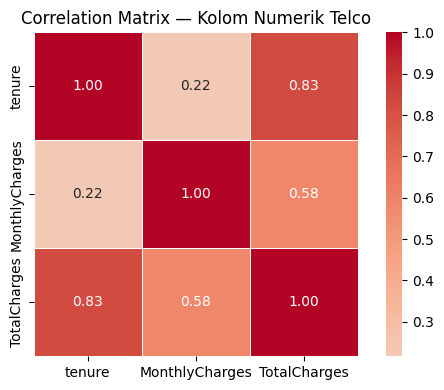


Korelasi terhadap TotalCharges:
TotalCharges      1.000000
tenure            0.825880
MonthlyCharges    0.580545
Name: TotalCharges, dtype: float64


In [179]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Hitung correlation matrix untuk kolom numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df_telco[num_cols].corr()

# Heatmap korelasi
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Kolom Numerik Telco')
plt.tight_layout()
plt.show()

# Identifikasi variabel dengan korelasi > 50% terhadap TotalCharges
print("\nKorelasi terhadap TotalCharges:")
print(corr['TotalCharges'].abs().sort_values(ascending=False))


### Scatter Plot — Variabel Target vs Variabel Independent

Scatter plot menampilkan hubungan antara dua variabel secara visual.
Digunakan untuk verifikasi visual setelah melihat korelasi.

```python
# Scatter plot satu variabel
sns.scatterplot(data=df, x='variabel_x', y='variabel_target')

# Scatter plot semua variabel independent terhadap target (dalam grid)
fig, axes = plt.subplots(1, len(fitur), figsize=(14, 4))
for ax, col in zip(axes, fitur):
    sns.scatterplot(data=df, x=col, y='target', ax=ax, alpha=0.4)
    ax.set_title(f'{col} vs target')
```

In [ ]:
# Scatter plot: tenure dan MonthlyCharges vs TotalCharges
fitur_x = ['tenure', 'MonthlyCharges']
target_y = 'TotalCharges'

df_plot = df_telco[fitur_x + [target_y]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, fitur_x):
    sns.scatterplot(data=df_plot, x=col, y=target_y, ax=ax, alpha=0.3, s=10)
    ax.set_title(f'{col} vs {target_y}')

plt.suptitle('Scatter Plot: Variabel Independent vs TotalCharges', fontsize=13)
plt.tight_layout()
plt.show()


### Boxplot per Kategori

Boxplot grouped by kategori menampilkan distribusi variabel numerik untuk setiap nilai variabel kategorik.
Berguna untuk melihat apakah ada **perbedaan signifikan** antar kelompok.

```python
# Boxplot variabel target berdasarkan variabel kategorik
sns.boxplot(data=df, x='variabel_kategori', y='variabel_target')
plt.title('Distribusi Target per Kategori')
plt.show()
```

In [ ]:
# Boxplot: MonthlyCharges berdasarkan Contract type
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_telco,
    x='Contract',
    y='MonthlyCharges',
    palette='Set2',
    hue='Contract',
)
plt.title('Distribusi MonthlyCharges berdasarkan Tipe Kontrak')
plt.xlabel('Tipe Kontrak')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

# Interpretasi: apakah ada perbedaan distribusi antar kategori?
print("Median MonthlyCharges per Contract:")
print(df_telco.groupby('Contract')['MonthlyCharges'].median().round(2))


---
## Ringkasan Topik Tambahan

| # | Topik | Fungsi Utama |
|---|---|---|
| 1 | Pivot Table | `pd.pivot_table(aggfunc=['count','sum'])` |
| 2 | Merge & Concat | `pd.concat(axis=1)`, `pd.merge(on=, how=)` |
| 3 | Export CSV | `df.to_csv(sep=',', index=False)` |
| 4 | str.extract & clean | `str.extract(r'^(\d+)\.')`, `str.replace(regex=True)` |
| 5 | Custom apply | `def fungsi()` + `df.apply(fungsi)` |
| 6 | Label encoding map | `df.map({'Outlier': 1, 'Not Outlier': 0})` |
| 7 | Outlier labeling | IQR → `result_outlier` → `is_outlier` |
| 8 | Statistika deskriptif | `df.describe()`, `df.agg()` |
| 9 | Correlation + visual | `df.corr()`, heatmap, scatter, boxplot |